# GC Example 03: Gaia EDR3 Proper Motion Query

**EPS Research — Milky Way Globular Cluster Corpus v1.3.1**

Gaia EDR3 provides precise proper motions (mu_alpha, mu_delta) for 170/174 clusters.
This example queries and visualizes the proper motion field across the sky.

**Corpus:** Flynn (2026), Zenodo DOI: 10.5281/zenodo.19907766  
**Sources:** Harris (1996/2010), Vasiliev & Baumgardt (2021), Baumgardt et al. (2023), Schiavon et al. (2024) APOGEE DR17  
**Dependencies:** Python 3, numpy, matplotlib

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'harris_gc_corpus_v1.3.2.jsonl': 'https://zenodo.org/records/21093446/files/harris_gc_corpus_v1.3.2.jsonl',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

clusters = []
with open('harris_gc_corpus_v1.3.2.jsonl') as f:
    for line in f:
        clusters.append(json.loads(line))
print(f"Total clusters: {len(clusters)}")


Total clusters: 174


In [3]:
# Extract Gaia EDR3 proper motions
pm_clusters = [c for c in clusters if c.get('gaia_edr3') and
               c['gaia_edr3'].get('mu_alpha_mas_yr') is not None]
print(f"Clusters with Gaia proper motions: {len(pm_clusters)}")

l_deg   = [c['position']['l_deg']                    for c in pm_clusters if c['position'].get('l_deg')]
b_deg   = [c['position']['b_deg']                    for c in pm_clusters if c['position'].get('b_deg')]
mu_tot  = [np.sqrt(c['gaia_edr3']['mu_alpha_mas_yr']**2 +
                   c['gaia_edr3']['mu_delta_mas_yr']**2)
           for c in pm_clusters
           if c['position'].get('l_deg') and c['gaia_edr3'].get('mu_alpha_mas_yr')]

print(f"Total proper motion range: {min(mu_tot):.2f} -- {max(mu_tot):.2f} mas/yr")
print(f"Median: {np.median(mu_tot):.2f} mas/yr")

Clusters with Gaia proper motions: 170
Total proper motion range: 0.10 -- 22.77 mas/yr
Median: 4.87 mas/yr


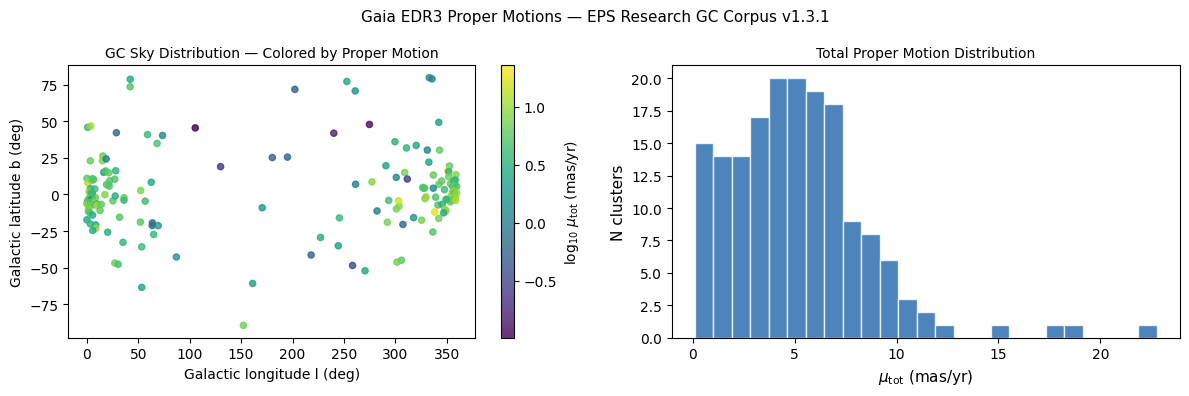

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sc = axes[0].scatter(l_deg, b_deg, c=np.log10(mu_tot), s=20,
                     cmap='viridis', alpha=0.8)
plt.colorbar(sc, ax=axes[0], label=r'log$_{10}$ $\mu_{\rm tot}$ (mas/yr)')
axes[0].set_xlabel('Galactic longitude l (deg)', fontsize=10)
axes[0].set_ylabel('Galactic latitude b (deg)', fontsize=10)
axes[0].set_title('GC Sky Distribution — Colored by Proper Motion', fontsize=10)

axes[1].hist(mu_tot, bins=25, color='#2166ac', alpha=0.8, edgecolor='white')
axes[1].set_xlabel(r'$\mu_{\rm tot}$ (mas/yr)', fontsize=11)
axes[1].set_ylabel('N clusters', fontsize=11)
axes[1].set_title('Total Proper Motion Distribution', fontsize=10)

plt.suptitle('Gaia EDR3 Proper Motions — EPS Research GC Corpus v1.3.1', fontsize=11)
plt.tight_layout()
plt.savefig('gc03_proper_motions.png', dpi=150, bbox_inches='tight')
plt.show()